# 05 Deep Learning Models

In this notebook, we train a 1D Convolutional Neural Network using raw physiological signal windows.

Unlike the previous machine learning notebook, this notebook does not use handcrafted statistical features. Instead, the neural network learns patterns directly from the time-series signals.

In [1]:
# Basic libraries for paths, arrays, tables, and plotting
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn is used only for splitting and evaluation
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# PyTorch libraries for deep learning
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Define main project folders
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

# Create folders if they do not already exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Check important files
print("Processed data folder:", PROCESSED_DATA_DIR)
print("X windows exists:", (PROCESSED_DATA_DIR / "X_windows.npy").exists())
print("y windows exists:", (PROCESSED_DATA_DIR / "y_windows.npy").exists())
print("Metadata exists:", (PROCESSED_DATA_DIR / "window_metadata.csv").exists())

Processed data folder: ..\data\processed
X windows exists: True
y windows exists: True
Metadata exists: True


In [4]:
# Random seeds help make the experiment more reproducible
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


In [5]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [6]:
# Load raw windowed signals created in Notebook 02
X_windows = np.load(PROCESSED_DATA_DIR / "X_windows.npy")
y_windows = np.load(PROCESSED_DATA_DIR / "y_windows.npy")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "window_metadata.csv")

# Print shapes to confirm data loaded correctly
print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)
print("Metadata shape:", metadata.shape)

X_windows shape: (2151, 21000, 4)
y_windows shape: (2151,)
Metadata shape: (2151, 9)


In [7]:
# Signal channel order from previous notebooks
SIGNAL_NAMES = ["ECG", "EDA", "Resp", "Temp"]

# Original WESAD labels used in this project
LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

# Deep learning needs labels starting from 0
LABEL_TO_INDEX = {
    1: 0,
    2: 1,
    3: 2
}

INDEX_TO_LABEL = {
    0: "Neutral / Baseline",
    1: "Stress",
    2: "Amusement"
}

print("Signals:", SIGNAL_NAMES)
print("Label mapping:", LABEL_TO_INDEX)

Signals: ['ECG', 'EDA', 'Resp', 'Temp']
Label mapping: {1: 0, 2: 1, 3: 2}


In [8]:
# Downsample factor reduces the time dimension
DOWNSAMPLE_FACTOR = 10

# Take every 10th sample from each window
X_downsampled = X_windows[:, ::DOWNSAMPLE_FACTOR, :]

# Convert to float32 because PyTorch models usually use float32
X_downsampled = X_downsampled.astype(np.float32)

print("Original X shape:", X_windows.shape)
print("Downsampled X shape:", X_downsampled.shape)

Original X shape: (2151, 21000, 4)
Downsampled X shape: (2151, 2100, 4)


In [9]:
# Convert labels into deep learning class indices
y_indices = np.array([LABEL_TO_INDEX[label] for label in y_windows])

print("Original labels:", np.unique(y_windows))
print("Deep learning labels:", np.unique(y_indices))

Original labels: [1 2 3]
Deep learning labels: [0 1 2]


In [10]:
# Subject IDs are used to split data by person
groups = metadata["subject_id"]

# GroupShuffleSplit keeps subjects separate between train and test
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_index, test_index = next(
    splitter.split(X_downsampled, y_indices, groups=groups)
)

# Create train and test arrays
X_train_raw = X_downsampled[train_index]
X_test_raw = X_downsampled[test_index]

y_train = y_indices[train_index]
y_test = y_indices[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

print("Training subjects:", sorted(groups_train.unique()))
print("Testing subjects:", sorted(groups_test.unique()))

Training shape: (1718, 2100, 4)
Testing shape: (433, 2100, 4)
Training subjects: ['S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S5', 'S7', 'S8', 'S9']
Testing subjects: ['S10', 'S4', 'S6']


In [11]:
# Check that no subject appears in both train and test sets
train_subjects = set(groups_train.unique())
test_subjects = set(groups_test.unique())

overlap_subjects = train_subjects.intersection(test_subjects)

print("Overlapping subjects:", overlap_subjects)

Overlapping subjects: set()


In [12]:
# Calculate channel-wise mean and std from training data only
train_mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
train_std = X_train_raw.std(axis=(0, 1), keepdims=True)

# Avoid division by zero
train_std[train_std == 0] = 1.0

# Apply normalization to train and test data
X_train_norm = (X_train_raw - train_mean) / train_std
X_test_norm = (X_test_raw - train_mean) / train_std

print("Training mean after normalization:", X_train_norm.mean(axis=(0, 1)))
print("Training std after normalization:", X_train_norm.std(axis=(0, 1)))

Training mean after normalization: [ 1.43236616e-06 -1.49168065e-02  4.84241400e-06  5.16598284e-01]
Training std after normalization: [1.0002334  0.9982444  1.0001501  0.85744816]


In [13]:
# Change shape from samples × time × channels to samples × channels × time
X_train_tensor = torch.tensor(X_train_norm).permute(0, 2, 1)
X_test_tensor = torch.tensor(X_test_norm).permute(0, 2, 1)

# Convert labels to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape:", X_test_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([1718, 4, 2100])
X_test_tensor shape: torch.Size([433, 4, 2100])
y_train_tensor shape: torch.Size([1718])
y_test_tensor shape: torch.Size([433])


In [14]:
# Batch size controls how many windows are processed at once
BATCH_SIZE = 32

# TensorDataset combines input data and labels
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader gives mini-batches during training
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 54
Number of testing batches: 14


In [15]:
# Count number of samples in each class
train_class_counts = np.bincount(y_train, minlength=3)
test_class_counts = np.bincount(y_test, minlength=3)

print("Training class counts:", train_class_counts)
print("Testing class counts:", test_class_counts)

for class_index, class_name in INDEX_TO_LABEL.items():
    print(class_name, "- train:", train_class_counts[class_index], "test:", test_class_counts[class_index])

Training class counts: [923 514 281]
Testing class counts: [231 130  72]
Neutral / Baseline - train: 923 test: 231
Stress - train: 514 test: 130
Amusement - train: 281 test: 72


In [16]:
# Create class weights from training distribution
num_classes = 3
total_train_samples = len(y_train)

class_weights = total_train_samples / (num_classes * train_class_counts)

# Convert class weights to PyTorch tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class weights: [0.62044059 1.11413748 2.03795967]


In [17]:
# 1D CNN model for physiological time-series classification
class StressCNN1D(nn.Module):
    def __init__(self, num_channels, num_classes):
        super().__init__()
        
        # First convolution block learns simple temporal patterns
        self.conv_block_1 = nn.Sequential(
            nn.Conv1d(num_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        
        # Second block learns more complex patterns
        self.conv_block_2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        
        # Third block creates higher-level signal features
        self.conv_block_3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        
        # Adaptive pooling converts variable time features into fixed size
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Final classifier predicts one of the three classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # x shape: batch × channels × time
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

In [18]:
# Model input has 4 channels: ECG, EDA, Resp, Temp
num_channels = X_train_tensor.shape[1]
num_classes = 3

model = StressCNN1D(
    num_channels=num_channels,
    num_classes=num_classes
).to(device)

# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer updates model parameters during training
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(model)

StressCNN1D(
  (conv_block_1): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
  

In [19]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    # Put model in training mode
    model.train()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for batch_X, batch_y in data_loader:
        # Move batch to CPU or GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Clear old gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and parameter update
        loss.backward()
        optimizer.step()
        
        # Save loss and predictions
        total_loss += loss.item() * batch_X.size(0)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate average loss and macro F1
    average_loss = total_loss / len(data_loader.dataset)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    accuracy = accuracy_score(all_targets, all_predictions)
    
    return average_loss, accuracy, macro_f1

In [20]:
def evaluate_model(model, data_loader, criterion, device):
    # Put model in evaluation mode
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    # No gradients are needed during evaluation
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # Move batch to CPU or GPU
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Save loss and predictions
            total_loss += loss.item() * batch_X.size(0)
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    # Calculate evaluation metrics
    average_loss = total_loss / len(data_loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    macro_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=0)
    
    return average_loss, accuracy, macro_f1, np.array(all_targets), np.array(all_predictions)

In [21]:
# Number of training epochs
NUM_EPOCHS = 25

# Store training history for plotting
history = []

best_test_f1 = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    # Train for one epoch
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    # Evaluate after each epoch
    test_loss, test_acc, test_f1, _, _ = evaluate_model(
        model,
        test_loader,
        criterion,
        device
    )
    
    # Save results for this epoch
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1
    })
    
    # Keep the best model based on test macro F1
    if test_f1 > best_test_f1:
        best_test_f1 = test_f1
        best_model_state = model.state_dict()
    
    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test F1: {test_f1:.4f}"
    )

Epoch 01/25 | Train Loss: 0.7950 | Train F1: 0.6068 | Test Loss: 1.0483 | Test F1: 0.4559
Epoch 02/25 | Train Loss: 0.5924 | Train F1: 0.7137 | Test Loss: 0.9463 | Test F1: 0.5029
Epoch 03/25 | Train Loss: 0.4913 | Train F1: 0.7602 | Test Loss: 1.1243 | Test F1: 0.4718
Epoch 04/25 | Train Loss: 0.4597 | Train F1: 0.7798 | Test Loss: 1.2996 | Test F1: 0.4457
Epoch 05/25 | Train Loss: 0.3701 | Train F1: 0.8292 | Test Loss: 1.9996 | Test F1: 0.4867
Epoch 06/25 | Train Loss: 0.3600 | Train F1: 0.8339 | Test Loss: 1.8661 | Test F1: 0.4690
Epoch 07/25 | Train Loss: 0.2975 | Train F1: 0.8549 | Test Loss: 2.3266 | Test F1: 0.4545
Epoch 08/25 | Train Loss: 0.2805 | Train F1: 0.8720 | Test Loss: 2.1359 | Test F1: 0.4033
Epoch 09/25 | Train Loss: 0.2425 | Train F1: 0.8756 | Test Loss: 3.0965 | Test F1: 0.4455
Epoch 10/25 | Train Loss: 0.2379 | Train F1: 0.9001 | Test Loss: 2.8628 | Test F1: 0.3868
Epoch 11/25 | Train Loss: 0.2364 | Train F1: 0.8853 | Test Loss: 2.8048 | Test F1: 0.5099
Epoch 12/2

In [22]:
# Convert training history into a table
history_df = pd.DataFrame(history)

history_df

,epoch,train_loss,train_accuracy,train_macro_f1,test_loss,test_accuracy,test_macro_f1
0,1,0.794953,0.641444,0.606774,1.048250,0.577367,0.455911
1,2,0.592377,0.742142,0.713702,0.946281,0.556582,0.502871
2,3,0.491267,0.798603,0.760207,1.124326,0.533487,0.471759
3,4,0.459723,0.813737,0.779848,1.299592,0.496536,0.445695
4,5,0.370105,0.857392,0.829230,1.999620,0.524249,0.486731
5,6,0.360044,0.862049,0.833865,1.866051,0.531178,0.468953
6,7,0.297503,0.878929,0.854938,2.326580,0.480370,0.454529
7,8,0.280484,0.892899,0.871985,2.135862,0.413395,0.403294
8,9,0.242519,0.895809,0.875567,3.096484,0.508083,0.445536
9,10,0.237943,0.919674,0.900106,2.862799,0.378753,0.386845


In [23]:
# Save training history for GitHub documentation
history_path = RESULTS_DIR / "dl_training_history.csv"

history_df.to_csv(history_path, index=False)

print("Saved training history to:", history_path)

Saved training history to: ..\results\dl_training_history.csv


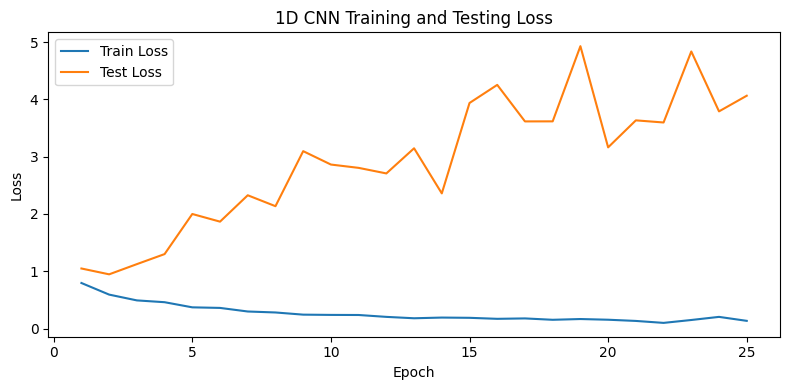

Saved figure to: ..\results\dl_loss_curve.png


In [24]:
# Plot loss curves to check learning behavior
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN Training and Testing Loss")
plt.legend()
plt.tight_layout()

output_path = RESULTS_DIR / "dl_loss_curve.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [25]:
# Restore the best model weights found during training
model.load_state_dict(best_model_state)

print("Best test macro F1 during training:", best_test_f1)

Best test macro F1 during training: 0.5129734095998634


In [26]:
# Final evaluation using the best saved model
test_loss, test_acc, test_f1, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

# Calculate additional metrics
test_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)

print("Final Test Accuracy:", round(test_acc, 4))
print("Final Test Macro Precision:", round(test_precision, 4))
print("Final Test Macro Recall:", round(test_recall, 4))
print("Final Test Macro F1:", round(test_f1, 4))

Final Test Accuracy: 0.3788
Final Test Macro Precision: 0.393
Final Test Macro Recall: 0.3793
Final Test Macro F1: 0.3584


In [27]:
# Detailed class-wise performance report
class_names = [
    INDEX_TO_LABEL[0],
    INDEX_TO_LABEL[1],
    INDEX_TO_LABEL[2]
]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                    precision    recall  f1-score   support

Neutral / Baseline       0.68      0.40      0.50       231
            Stress       0.32      0.32      0.32       130
         Amusement       0.18      0.42      0.25        72

          accuracy                           0.38       433
         macro avg       0.39      0.38      0.36       433
      weighted avg       0.49      0.38      0.41       433



In [28]:
# Save the report as a text file
report_path = RESULTS_DIR / "dl_classification_report.txt"

with open(report_path, "w") as file:
    file.write("Model: 1D CNN\n\n")
    file.write(report)

print("Saved classification report to:", report_path)

Saved classification report to: ..\results\dl_classification_report.txt


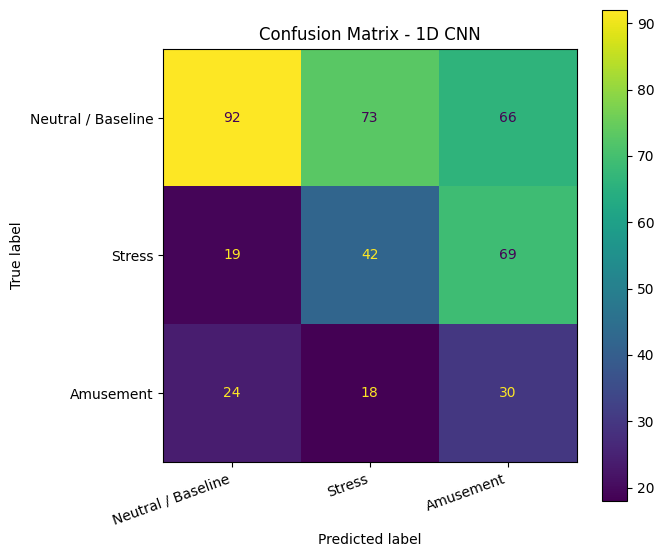

Saved confusion matrix to: ..\results\dl_confusion_matrix.png


In [29]:
# Confusion matrix shows correct and incorrect predictions
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - 1D CNN")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "dl_confusion_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved confusion matrix to:", output_path)

In [30]:
# Save final deep learning result summary
dl_summary = pd.DataFrame([
    {
        "model": "1D CNN",
        "accuracy": test_acc,
        "macro_precision": test_precision,
        "macro_recall": test_recall,
        "macro_f1": test_f1,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "downsample_factor": DOWNSAMPLE_FACTOR,
        "input_channels": num_channels,
        "input_time_steps": X_train_tensor.shape[2],
        "training_samples": X_train_tensor.shape[0],
        "testing_samples": X_test_tensor.shape[0],
        "training_subjects": ", ".join(sorted(groups_train.unique())),
        "testing_subjects": ", ".join(sorted(groups_test.unique()))
    }
])

summary_path = RESULTS_DIR / "dl_summary.csv"

dl_summary.to_csv(summary_path, index=False)

dl_summary

,model,accuracy,macro_precision,macro_recall,macro_f1,epochs,batch_size,downsample_factor,input_channels,input_time_steps,training_samples,testing_samples,training_subjects,testing_subjects
0,1D CNN,0.378753,0.39303,0.379337,0.358429,25,32,10,4,2100,1718,433,"S11, S13, S14, S15, S16, S17, S2, S3, S5, S7, ...","S10, S4, S6"


In [31]:
# Save PyTorch model locally
model_path = MODELS_DIR / "stress_cnn_1d.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "train_mean": train_mean,
    "train_std": train_std,
    "signal_names": SIGNAL_NAMES,
    "label_mapping": INDEX_TO_LABEL,
    "downsample_factor": DOWNSAMPLE_FACTOR
}, model_path)

print("Saved model locally to:", model_path)

Saved model locally to: ..\models\stress_cnn_1d.pt


In [32]:
# Select one test sample
sample_index = 0

sample_X = X_test_tensor[sample_index].unsqueeze(0).to(device)
sample_true_label = y_test_tensor[sample_index].item()

# Predict one sample
model.eval()

with torch.no_grad():
    output = model(sample_X)
    probabilities = torch.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1).item()

print("True label:", INDEX_TO_LABEL[sample_true_label])
print("Predicted label:", INDEX_TO_LABEL[predicted_label])
print("Probabilities:", probabilities.cpu().numpy())

True label: Neutral / Baseline
Predicted label: Amusement
Probabilities: [[6.6299841e-02 1.2967409e-07 9.3369997e-01]]


In [37]:
# Load ML model comparison results if available
ml_results_path = RESULTS_DIR / "ml_model_comparison.csv"

if ml_results_path.exists():
    ml_results = pd.read_csv(ml_results_path)
    
    # Take best ML model
    best_ml_row = ml_results.sort_values(by="macro_f1", ascending=False).iloc[0]
    
    comparison_df = pd.DataFrame([
        {
            "model": best_ml_row["model"],
            "type": "Classical ML",
            "accuracy": best_ml_row["accuracy"],
            "macro_f1": best_ml_row["macro_f1"]
        },
        {
            "model": "1D CNN",
            "type": "Deep Learning",
            "accuracy": test_acc,
            "macro_f1": test_f1
        }
    ])

    
    comparison_path = RESULTS_DIR / "ml_vs_dl_comparison.csv"
    comparison_df.to_csv(comparison_path, index=False)
    
    print(comparison_df)
else:
    print("ML comparison file not found. Run Notebook 04 first.")

               model           type  accuracy  macro_f1
0  Gradient Boosting   Classical ML  0.706697  0.577475
1             1D CNN  Deep Learning  0.378753  0.358429


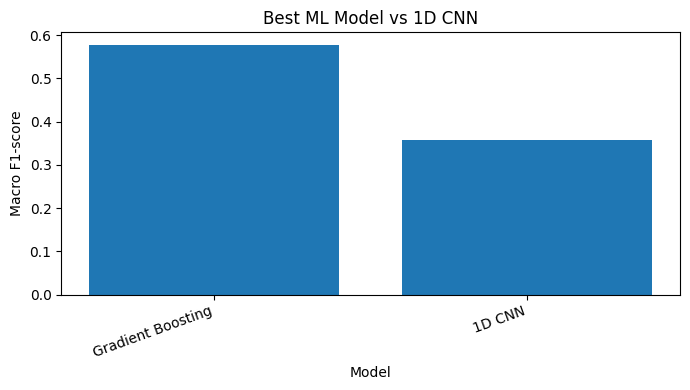

Saved figure to: ..\results\ml_vs_dl_macro_f1.png


In [38]:
# Plot comparison only if comparison_df exists
if "comparison_df" in globals():
    plt.figure(figsize=(7, 4))
    plt.bar(comparison_df["model"], comparison_df["macro_f1"])
    plt.xlabel("Model")
    plt.ylabel("Macro F1-score")
    plt.title("Best ML Model vs 1D CNN")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    
    output_path = RESULTS_DIR / "ml_vs_dl_macro_f1.png"
    plt.savefig(output_path, dpi=300)
    plt.show()
    
    print("Saved figure to:", output_path)